# Machine Learning (ML) for Biosignature Detection in Icy Ocean Worlds:

## Engineering Biotic & Abiotic py-MS Features for Binary Classification:

### Introduction:
In this Jupyter notebook, I prepare, clean, engineer, and explore pyrolysis-Mass Spectrometry (py-MS) features generated by [`preprocess.py`](../mlbiosig/preprocess.py) using biotic and abiotic mass spectral CSV files. Feature engineering is a critical stage in machine learning, as transforming raw features into chemically meaningful inputs minimises overfitting, reduces noise, lowers feature dimensionality, converts categorical information into numerical data, and consequently improves model accuracy and interpretability.

Instead of using the whole sample dataset to generate py-MS features, this notebook focuses on a more balanced dataset of 32 biotic and 14 abiotic samples in this work, where the entire sample set is described in the following [documentation](../docs/total-sample-breakdown.md). This provides a benchmark sample set to develop and validate an overarching feature engineering framework, prior to compressing these steps into a script within my [`mlbiosig`](../mlbiosig/) Python package.

**Reproducibility Statement:** All results, numerical values, figures, and plots in this notebook are fully reproducible using the provided code and available data within the the root repository.

### Imports:

In [1]:
# Imports
from mlbiosig import samples_labels, build_features
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import VarianceThreshold
from sklearn.preprocessing import LabelEncoder, RobustScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### Loading Dataset:

There are a total of 140 biotic and 14 abiotic samples. Out of the 140 biotics, I manually choose a subset defined in `biotic_names` below that best represent the biological diversity of the overall dataset. Hence, the dataset in this work consists of a total of 46 py-GC-MS samples, with

* 32 biotics: ranging from microbial samples (e.g. _Spirulina_, _Chlorella_, _Shewanella_), kerogens, biochar (e.g. chesnut wood, barley straw, rice husk), resins, waxes, biotic organics (coal, shale), and membrane lipids.

* 14 abiotics: including petroleum-derived waxes, plastics, meteorites, and minerals (e.g. Calcite) samples.

In [2]:
# Obtain biotic & abiotic py-GC-MS mass spectra CSV filepaths:
filepaths, labels = samples_labels()  # filepaths and label ('biotic'/'abiotic')
print(
    f"Total Samples: {len(filepaths)} | Total Biotic: {labels.count('biotic')}| Total Abiotic: {labels.count('abiotic')}"
)

Total Samples: 154 | Total Biotic: 140| Total Abiotic: 14


In [3]:
# Chosen 32 biotic sample filenames:
microbials = [
    "041121_SP_0",
    "091121_SP_21H",
    "101221_SP_48H_1",
    "200122_SP_NACL_24H",  # spirulina
    "241121_CH",
    "081221_CH_24H",
    "CHLORBACT_MGCL2_110825",  # chlorella
    "SHEW_1",
    "SHEW_2",
    "SHEW_3",
    "SHEW_4",
    "SHEW_5",
]  # shewanella

biopolymers = [
    "MEMBRANE_LIPID",
    "MEMBRANE_LIPID_MGCL2_150",  # membrane lipids
    "CELLULOSE_20231016",  # cellulose
    "LIGNIN_20231018",
]  # biotic lignin

biochar = [
    "BARLEYSTRAW_150_231106",  # barley straw
    "CHESTNUTWOOD_300_231107",  # chestnut wood
    "RICE_HUSK_200_20231122",  # rice husk
    "PINE_BARK_200_20231124",  # pine bark
    "EUCALYPTUSBARK_300_231109",
]  # eucalyptus

coals = ["DM_031125", "HIGHVOLDM1"]

kerogens = [
    "080206GRSSPLT",  # green river shale
    "CBN1_4229.4FT_650_WHOLE",
    "CD3_650_WHOLE",
    "LF1_23-4M_650_WHOLE",
    "RMP1_665-4M_650_WHOLE",
]  # kerogens

waxes_resins = [
    "AMBER_140726_3",
    "FRANK_140726_2",  # resins
    "BEESWAXNAT181018_2",
    "CARNAUBA181018_4",
]  # waxes

biotic_names = np.concatenate(
    (microbials, biopolymers, biochar, coals, kerogens, waxes_resins), axis=None
)

# Re-packaging biotic & abiotic filepaths + corresponding label:
balanced_filepaths = []
balanced_labels = []

for filepath, label in zip(filepaths, labels):
    filename = filepath.split("/")[-1].replace(".CSV", "")
    if label == "abiotic" or filename in biotic_names:  # same number of abiotic
        balanced_filepaths.append(filepath)
        balanced_labels.append(label)

print(
    f"Subset Samples: {len(balanced_filepaths)} | Subset Biotic: {balanced_labels.count('biotic')}| Total Abiotic: {balanced_labels.count('abiotic')}"
)

Subset Samples: 46 | Subset Biotic: 32| Total Abiotic: 14


### Feature Creation & Data Preprocessing:

Using the `preprocess` pipeline, I generate max-normalised py-MS vectors stacked into a feature matrix. The vectors are created from the subset of py-GC-MS mass spectral CSV files in `balanced_filepaths` and `balanced_labels`, whereby each column in the feature matrix represents the mass-to-charge ratio ($m/z$) with a final column reserved for the sample class (i.e., biotic or abiotic), rows are the sample name, and entries are the summed and normalised intensities of each $m/z$ detected in the sample.

`preprocess` also flags samples with unusual spectra, which are ultimately omitted and separately compiled for further investigation.

In [4]:
# Build feature matrix and collect flagged samples:
feature_matrix, flags = build_features(balanced_filepaths, balanced_labels)

# Check feature shape:
# columns = m/z values, rows = sample name
if feature_matrix.shape[0] == len(balanced_filepaths):
    print(f"\nFeature matrix shape: {feature_matrix.shape}")
else:
    raise ValueError(
        rf"Feature matrix rows is incorrect size {feature_matrix.shape}), should be ({len(balanced_filepaths)}, {feature_matrix.shape[1]})."
    )

# Output flagged samples with unusual mass spectra:
if flags:
    print(f"{len(flags)} samples flagged:")
else:
    print("No samples flagged.")

Preprocessing py-GC-MS samples:   0%|          | 0/46 [00:00<?, ?sample/s]


Feature matrix shape: (46, 5309)
No samples flagged.


In [5]:
# Print header for first 10 samples:
feature_matrix.head(10)

m_z,50.1,50.3,50.8,51.0,51.1,51.3,52.0,52.1,52.2,52.3,...,14.8,19.4,14.1,16.3,17.3,27.1,28.2,29.3,32.2,40.0
041121_SP_0,0.196884,0.000166,0.000001,0.000445,0.350330,0.000039,0.000741,0.155981,0.155879,0.000102,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
080206GRSSPLT,0.015949,0.000000,0.000000,0.000000,0.080974,0.000000,0.000000,0.040579,0.000132,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
081221_CH_24H,0.167491,0.000020,0.000000,0.000136,0.307936,0.000004,0.000050,0.228654,0.040986,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
091121_SP_21H,0.175225,0.000022,0.000000,0.000034,0.282388,0.000000,0.000224,0.294299,0.000000,0.000019,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
101221_SP_48H_1,0.163892,0.000009,0.000000,0.000029,0.306565,0.000009,0.000037,0.276287,0.000000,0.000006,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
200122_SP_NACL_24H,0.156089,0.000026,0.000000,0.000008,0.243271,0.000000,0.000088,0.078379,0.194584,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
241121_CH,0.156857,0.000020,0.000000,0.000016,0.261416,0.000000,0.000029,0.081231,0.193601,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
AMBER_140726_3,0.000000,0.002012,0.000012,0.000930,0.000000,0.001330,0.000000,0.009433,0.046293,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
BARLEYSTRAW_150_231106,0.003175,0.000016,0.000000,0.000000,0.003734,0.000000,0.000181,0.002054,0.000348,0.000029,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
BEESWAXNAT181018_2,0.007016,0.000238,0.000090,0.004828,0.012727,0.000240,0.003308,0.007675,0.000000,0.000490,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


I will now assign the feature matrix to `df` and check if there are any duplicate rows. As the features themselves were constructed by me in `preprocess`, there should **not** be any duplicates especially if the feature matrix's shape was generated correctly. However, for completeness, I will check for duplicated sample rows:

In [6]:
# Check for duplicated rows (there should not be any as per `preprocess`)
df = feature_matrix
df.duplicated().sum()

np.int64(0)

### Feature Engineering

The target in this work is the `label` identifying sample class i.e., whether they are biotic/abiotic.

In [7]:
y = df["label"]  # target
X = df.drop(columns=["label"])  # features

X.shape

(46, 5308)

**Spectral Binning**

As there are over $5,000$ $m/z$ columns, and therefore features, the dimensionality of the feature matrix is incredibly large.  Merging and/or dropping features becomes vital in increasing a model's robustness to outliers and acts as a preventitive to overfitting.

The first method for reducing the number of features is by binning fractional $m/z$ values into integer $m/z$ columns i.e., $$m/z \in [50.1, 50.3, 50.8] \rightarrow m/z \; 50$$

In [8]:
print(f"Features before binning: {X.shape[1]} m/z columns")

# Round fractional m/z column names to nearest integer
X.columns = X.columns.astype(float).round(0).astype(int)
# Transpose rows + sum intensities of columns within integer bins
X_binned = X.T.groupby(level=0).sum().T

print(f"Features after binning: {X_binned.shape[1]} m/z columns")
print(f"Feature Reduction: {((X.shape[1]-X_binned.shape[1])/X.shape[1])*100:.1f} %")

X_binned.head(10)

Features before binning: 5308 m/z columns
Features after binning: 541 m/z columns
Feature Reduction: 89.8 %


m_z,10,11,12,13,14,15,16,17,18,19,...,541,542,543,544,545,546,547,548,549,550
041121_SP_0,0.000000,0.00000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000142,0.000158,0.000105,0.000123,0.000112,0.000089,0.000332,0.000166,0.005011,0.000278
080206GRSSPLT,0.000000,0.00000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
081221_CH_24H,0.000000,0.00000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000089,0.000107,0.000052,0.000105,0.000062,0.000089,0.000152,0.000095,0.002013,0.000144
091121_SP_21H,0.000000,0.00000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000056,0.000049,0.000040,0.000039,0.000046,0.000042,0.000120,0.000087,0.002264,0.000152
101221_SP_48H_1,0.000000,0.00000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000053,0.000049,0.000043,0.000039,0.000037,0.000050,0.000110,0.000077,0.001366,0.000064
200122_SP_NACL_24H,0.000000,0.00000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000054,0.000041,0.000029,0.000035,0.000035,0.000041,0.000079,0.000065,0.001678,0.000080
241121_CH,0.000000,0.00000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000053,0.000043,0.000044,0.000045,0.000038,0.000054,0.000106,0.000101,0.002345,0.000105
AMBER_140726_3,0.000000,0.00000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000260,0.000359,0.000233,0.000310,0.000258,0.000311,0.000417,0.000434,0.005556,0.001070
BARLEYSTRAW_150_231106,0.000036,0.00007,0.000803,0.00041,0.026411,0.003501,0.015404,0.031758,0.134113,0.000634,...,0.000028,0.000023,0.000025,0.000022,0.000022,0.000020,0.000027,0.000026,0.000246,0.000030
BEESWAXNAT181018_2,0.000000,0.00000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000400,0.000415,0.000433,0.000464,0.000466,0.000499,0.001399,0.000982,0.021790,0.000181


**Encoding Categorical Target (`label`)**

As most ML algorithms only process numerical data, the `label` (assigning biotic/abiotic to each sample) must be encoded by assigning integers to each category. 

I choose label encoding via `LabelEncoder()` as this is typically reserved for target variables. This is because other encoders, such as `OneHotEncoder()`, create new binary columns whereas label encoding ensures the target remains a single vector.

In [9]:
# Converting target to numerical data via LabelEncoder:
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# Check classes are abiotic (0) and biotic (1):
print(le.classes_)

['abiotic' 'biotic']


### Splitting Dataset into Train/Test:

As the overall dataset (83 samples) is particularly small, I will be using a stratified k-fold cross-validation approach when I begin to build and train my classifiers. Hence, alongside the training and validation set, I will assign 20% of all samples to the test set via `test_size=0.2`.

In [10]:
# Splitting dataset:
# ensuring dataset is shuffled as biotic-then-abiotic order
# of samples
X_train, X_test, y_train, y_test = train_test_split(
    X_binned,
    y_encoded,
    test_size=0.2,
    random_state=42,
    shuffle=True,
    stratify=y_encoded,
)

print(f"Feature Training Set: {X_train.shape}")
print(f"Feature Testing Set: {X_test.shape}")

Feature Training Set: (36, 541)
Feature Testing Set: (10, 541)


### Exploratory Data Analysis (EDA)

**Dropping Known Contaminated Features**

I will now screen for known instrumental and background contaminants that have been well-documented in literature, such as Agilent's own GC/MS Troubleshooting Guide (Agilent Technologies 2024). I first examine the $m/z$ features with the highest variances using Pandas `.var()`, to determine whether they represent genuine organic geochemistry or systematic instrumental noise that could introduce bias.

In [11]:
# Calculate variance for each m/z column:
variances = X_train.var(axis=0)

# Obtain m/z values that are the highest variance features:
n_feat = 20
high_var_feat = variances.sort_values(ascending=False).head(n_feat)
print(rf"Top {n_feat} highest variance m/z values:")
print(high_var_feat)

Top 20 highest variance m/z values:
m_z
55     0.182511
57     0.149391
207    0.147464
28     0.142857
91     0.130971
95     0.106825
69     0.081634
107    0.068795
81     0.066219
41     0.062037
71     0.058264
128    0.056781
84     0.054980
115    0.054916
45     0.053799
68     0.053589
67     0.052998
64     0.051916
70     0.051343
43     0.050807
dtype: float64


The high-variance $m/z$ features are very revealing of both rich chemical diversity as well as possible instrumental artefacts present across biotic and abiotic samples:
* Aliphatic Hydrocarbons: $m/z \; 55, 57, 69, 70$ typically arising from organic matter like kerogens (Barupal 2010).
* Aromatic Hydrocarbons: $m/z \; 91$ as one of a series of alkylbenzenes arising from degraded organic molecules (Solli 1980).
* Atmospheric Contamination: $m/z \; 28$ as nitrogen ($\text{N}_2$), arising from residual air or possible air leaks.
* Instrumental Artefacts: $m/z \; 207$ as the frequently encountered Dimethylpolysixolane (PDMS) caused by GC-MS column bleed via thermal degradation. 
* Diffusion Pump Fluid: $m/z \; 77, 94$ as diffusion pump fluid which may have backstreamed due to improper venting.

I will now investigate the flagged $m/z$ values above as well as their compiled companion fragment ions listed in Agilent Technologies (2024) to determine the presence of contamination.

In [12]:
# m/z values for atmospheric contaminants:
mz_14 = X_train[14]  # N
mz_16 = X_train[16]  # O
mz_18 = X_train[18]  # H2O
mz_28 = X_train[28]  # N2
mz_32 = X_train[32]  # O2
mz_44 = X_train[44]  # CO2

# m/z values for diffusion pump fluid:
mz_77 = X_train[77]
mz_94 = X_train[94]
mz_115 = X_train[115]
mz_141 = X_train[141]
mz_168 = X_train[168]
mz_170 = X_train[170]
mz_262 = X_train[262]
mz_354 = X_train[354]
mz_446 = X_train[446]

# m/z values for PDMS (GC column bleed):
mz_73 = X_train[73]
mz_147 = X_train[147]
mz_207 = X_train[207]
mz_221 = X_train[221]
mz_281 = X_train[281]
mz_295 = X_train[295]
mz_355 = X_train[355]
mz_429 = X_train[429]

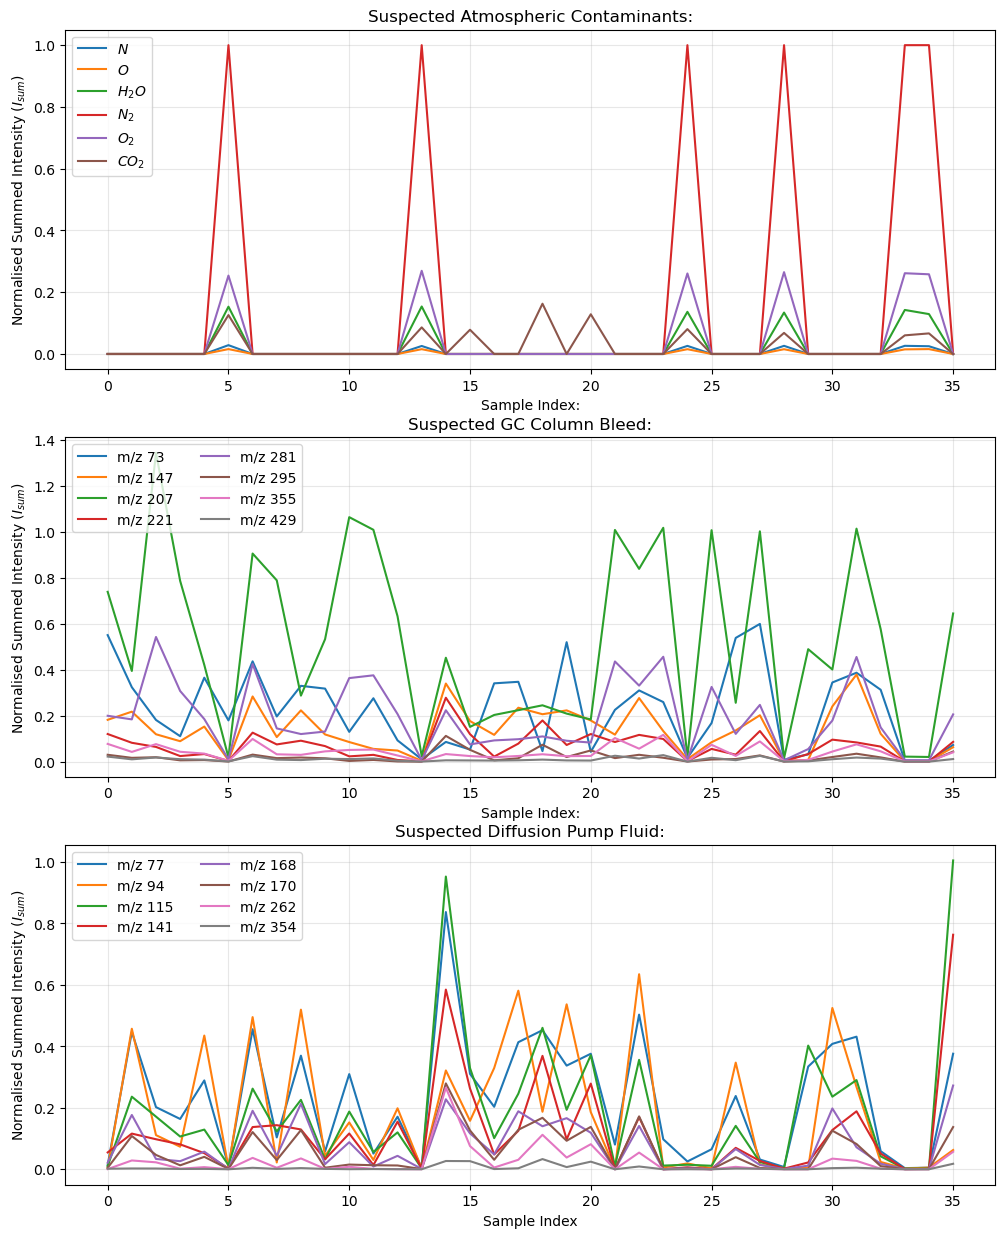

In [13]:
# Plotting:
fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(12, 15))

# Atmospheric/air leak contamination:
axes[0].plot(mz_14.values, label=r"$N$")
axes[0].plot(mz_16.values, label=r"$O$")
axes[0].plot(mz_18.values, label=r"$H_2O$")
axes[0].plot(mz_28.values, label=r"$N_2$")
axes[0].plot(mz_32.values, label=r"$O_2$")
axes[0].plot(mz_44.values, label=r"$CO_2$")
axes[0].set_title("Suspected Atmospheric Contaminants:")
axes[0].set_xlabel("Sample Index:")
axes[0].set_ylabel(r"Normalised Summed Intensity ($I_{sum}$)")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# GC Column Bleed contaminants:
axes[1].plot(mz_73.values, label="m/z 73")
axes[1].plot(mz_147.values, label="m/z 147")
axes[1].plot(mz_207.values, label="m/z 207")
axes[1].plot(mz_221.values, label="m/z 221")
axes[1].plot(mz_281.values, label="m/z 281")
axes[1].plot(mz_295.values, label="m/z 295")
axes[1].plot(mz_355.values, label="m/z 355")
axes[1].plot(mz_429.values, label="m/z 429")
axes[1].set_title("Suspected GC Column Bleed:")
axes[1].set_xlabel("Sample Index:")
axes[1].set_ylabel(r"Normalised Summed Intensity ($I_{sum}$)")
axes[1].legend(ncol=2)
axes[1].grid(True, alpha=0.3)

# Diffusion pump fluid:
axes[2].plot(mz_77.values, label="m/z 77")
axes[2].plot(mz_94.values, label="m/z 94")
axes[2].plot(mz_115.values, label="m/z 115")
axes[2].plot(mz_141.values, label="m/z 141")
axes[2].plot(mz_168.values, label="m/z 168")
axes[2].plot(mz_170.values, label="m/z 170")
axes[2].plot(mz_262.values, label="m/z 262")
axes[2].plot(mz_354.values, label="m/z 354")
axes[2].set_title("Suspected Diffusion Pump Fluid:")
axes[2].set_xlabel("Sample Index")
axes[2].set_ylabel(r"Normalised Summed Intensity ($I_{sum}$)")
axes[2].legend(ncol=2)
axes[2].grid(True, alpha=0.3)

It is flawlessly clear that the three panels above confirm the presence of atmospheric contamination, GC column bleed, and diffusion pump fluid across the investigated $m/z$ values, given their synchronised presence and almost identical intensity profiles across the same samples.

* First Panel: The observed fragment ions ($m/z \; 14, 16, 18, 28, 32, 44$) are characteristic of background species ranging from $\text{H}_2\text{O}$ to $\text{CO}_2$. They appear across the same sample indices, suggesting changes in the instrument's background conditions (i.e., air leaks) rather than sample-related chemistry.

* Second Panel: The observed fragment ions ($m/z \; 73, 147, 207, 221, 281, 295, 354, 446$) form the characteristic siloxane fragmentation pattern consistent with PDMS contamination, which arises due to GC column bleed and/or septum bleed. Moreover, the flat plateaus further support this as the MS detector is saturated by the high intensity of column bleed.

* Third Panel: Similarly, the observed fragment ions ($m/z \; 77, 94, 115, 141, 168, 170, 262, 354, 446$) appear across the same subset of samples.

In [14]:
# Contaminated m/z features:
contaminants = [
    18,
    28,
    32,
    44,  # atmospheric/background
    77,
    94,
    115,
    141,
    168,
    170,
    262,
    354,
    446,  # diffusion pump
    73,
    147,
    207,
    221,
    281,
    295,
    355,
    429,
]  # GC column bleed

# Dropping contaminated feature from training data:
X_train_clean = X_train.drop(columns=contaminants)
X_test_clean = X_test.drop(columns=contaminants)

print("Training features before contaminant removal:", X_train.shape[1])
print("Training features after contaminant removal:", X_train_clean.shape[1])

Training features before contaminant removal: 541
Training features after contaminant removal: 520


**Dropping Near-Zero Variance Features**

While certain $m/z$ values serve as fingerprints for known instrumental and atmospheric contaminants, there is also a possibility that a set of $m/z$ values with considerably low variance encodes noise rather than discriminative chemical information as well.

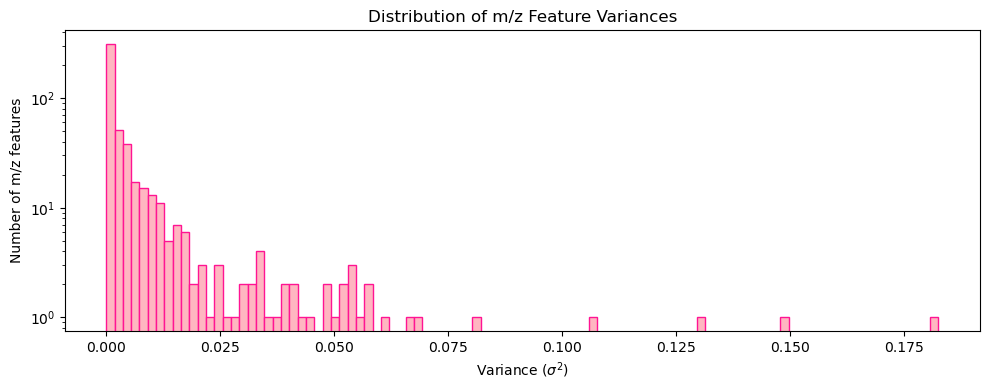

In [15]:
# Calculate new variance for each m/z column:
variances = X_train_clean.var(axis=0)

# Plot distribution of variances:
plt.figure(figsize=(10, 4))
plt.hist(variances, bins=100, color="lightpink", edgecolor="deeppink")
plt.xlabel(rf"Variance ($\sigma^2$)")
plt.ylabel("Number of m/z features")
plt.title("Distribution of m/z Feature Variances")
plt.yscale("log")  # applying log as most variances appear very small
plt.tight_layout()
plt.show()

It is incredibly difficult to see where a break-point between noise and true chemical signal occurs in the histogram above, as the variance appears to have an exponential distribution on a macro-scale.

I will therefore focus on the low-variance tail, $\sigma^2 \in [0, 0.05]$, to determine where both the break-point occurs and the true signal emerges.

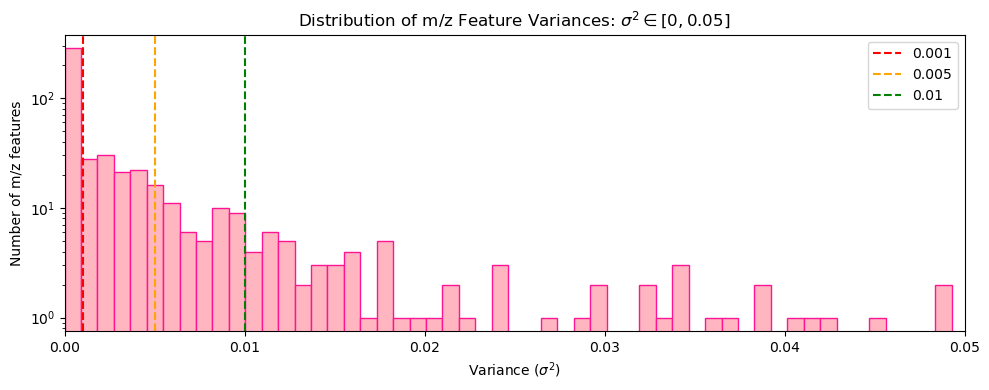

In [16]:
# Zoom into low-variance tail:
plt.figure(figsize=(10, 4))
plt.hist(variances, bins=200, color="lightpink", edgecolor="deeppink")
plt.xlabel(rf"Variance ($\sigma^2$)")
plt.ylabel("Number of m/z features")
plt.title(rf"Distribution of m/z Feature Variances: $\sigma^2 \in [0, 0.05]$")
plt.xlim(0, 0.05)  # low variances
plt.yscale("log")
plt.axvline(x=0.001, color="red", linestyle="--", label="0.001")
plt.axvline(x=0.005, color="orange", linestyle="--", label="0.005")
plt.axvline(x=0.01, color="green", linestyle="--", label="0.01")
plt.legend()
plt.tight_layout()
plt.show()

The break-point at $\sigma^2 > 0.001$ in the plot above is a wonderful demonstration of where features encoding baseline noise cluster close to zero with a gap before the chemical signal begins. This therefore illustrates that a threshold separating noise and signal exists.

To impose a selection method for removing non-informative noise revealed in my variance analysis, the `VarianceThreshold` tool (scikit-learn developers 2026) can be used as a selector for removing low-variance features. Based on the plot above, I will therefore set my threshold to $0.001$.

In [17]:
print(
    f"Training features before variance threshold: {X_train_clean.shape[1]} m/z columns"
)

# Remove features where variance across sample intensities is below threshold
selector = VarianceThreshold(threshold=0.001)
X_train_selected = selector.fit_transform(X_train_clean)  # fit on training
X_test_selected = selector.transform(X_test_clean)  # apply transformation on test

# Convert kept columns back to pandas dataframe with column names:
high_var_cols = X_train_clean.columns[selector.get_support()]
X_train_reduced = pd.DataFrame(
    X_train_selected, columns=high_var_cols, index=X_train_clean.index
)
X_test_reduced = pd.DataFrame(
    X_test_selected, columns=high_var_cols, index=X_test_clean.index
)

print(
    f"Training features after variance threshold: {X_train_reduced.shape[1]} m/z columns"
)

Training features before variance threshold: 520 m/z columns
Training features after variance threshold: 234 m/z columns


**Box Plots of Features**

Box plots enable the visual exploration of the overall $m/z$ distribution across samples as well as the detection of possible outliers. As there are $<200$ features, I will examine $\sim 10$ $m/z$ feature distributions to determine whether Interquartile Range (IQR) caps/domain caps should be imposed to remove outliers.

<function matplotlib.pyplot.show(close=None, block=None)>

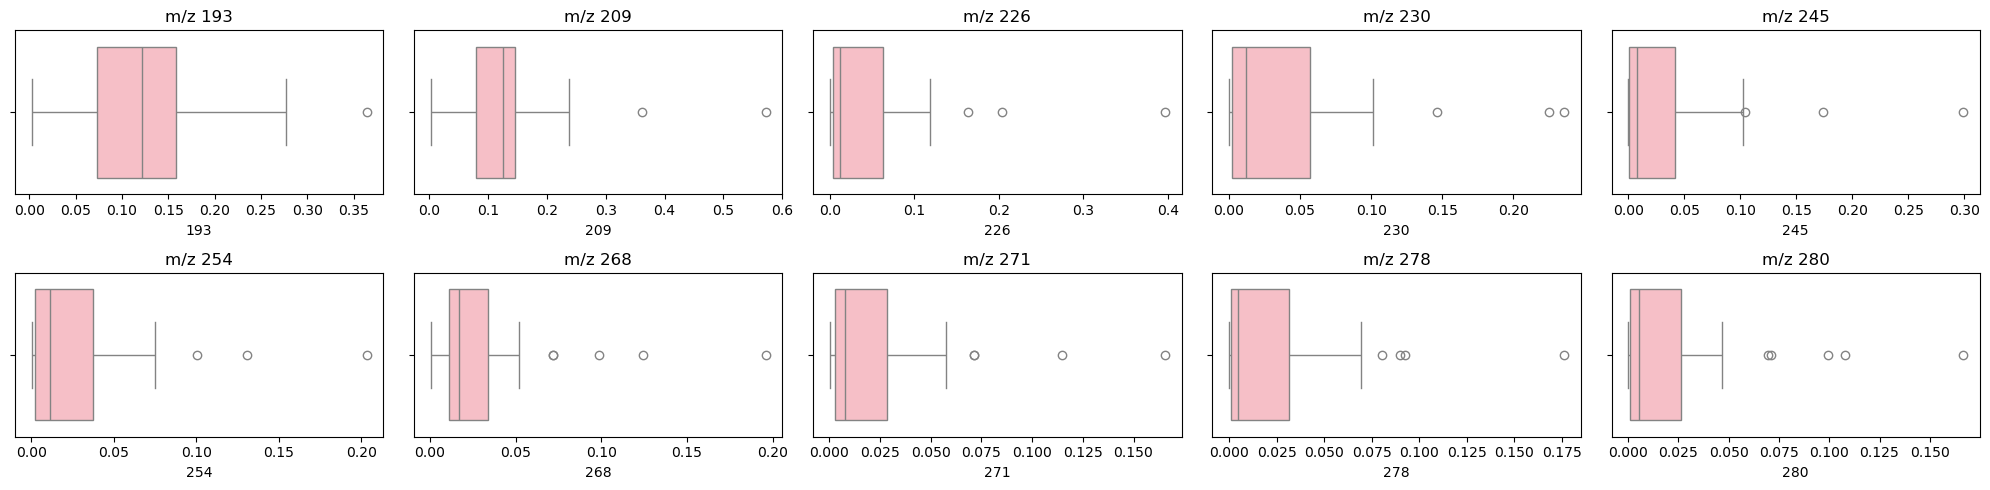

In [18]:
# Box plots of selected m/z features:
outlier_features = [
    193,
    209,
    226,
    230,
    245,
    254,
    268,
    271,
    278,
    280,
]  # manually selected features
fig, axes = plt.subplots(nrows=2, ncols=5, figsize=(20, 5))
axes = axes.flatten()
for i, mz in enumerate(outlier_features):
    sns.boxplot(x=X_train_reduced[mz], ax=axes[i], color="lightpink")
    axes[i].set_title(f"m/z {mz}")
plt.tight_layout()
plt.show

Although several $m/z$ features above exhibit $I_{\text{sum}}$ values beyond the IQR-defined ranges and therefore thresholds, these values will not be removed or subject to IQR/domain caps. In py-GC-MS datasets, such outliers may represent genuine chemical variation or biomarker signals rather than measurement errors, especially given the prior removal of well-documented and known contaminants on this data. 

These extreme outlier values were therefore kept in order to preserve potential organic chemistry. This is further reinforced below via strip plot analysis, where such outliers are not randomly distributed but instead belong within a specific class (biotic or abiotic). It is also interesting to observe there is substantial overlap between both classes across most of the IQR-defined range, while their discriminative separation is far more evident within the outlier tails.

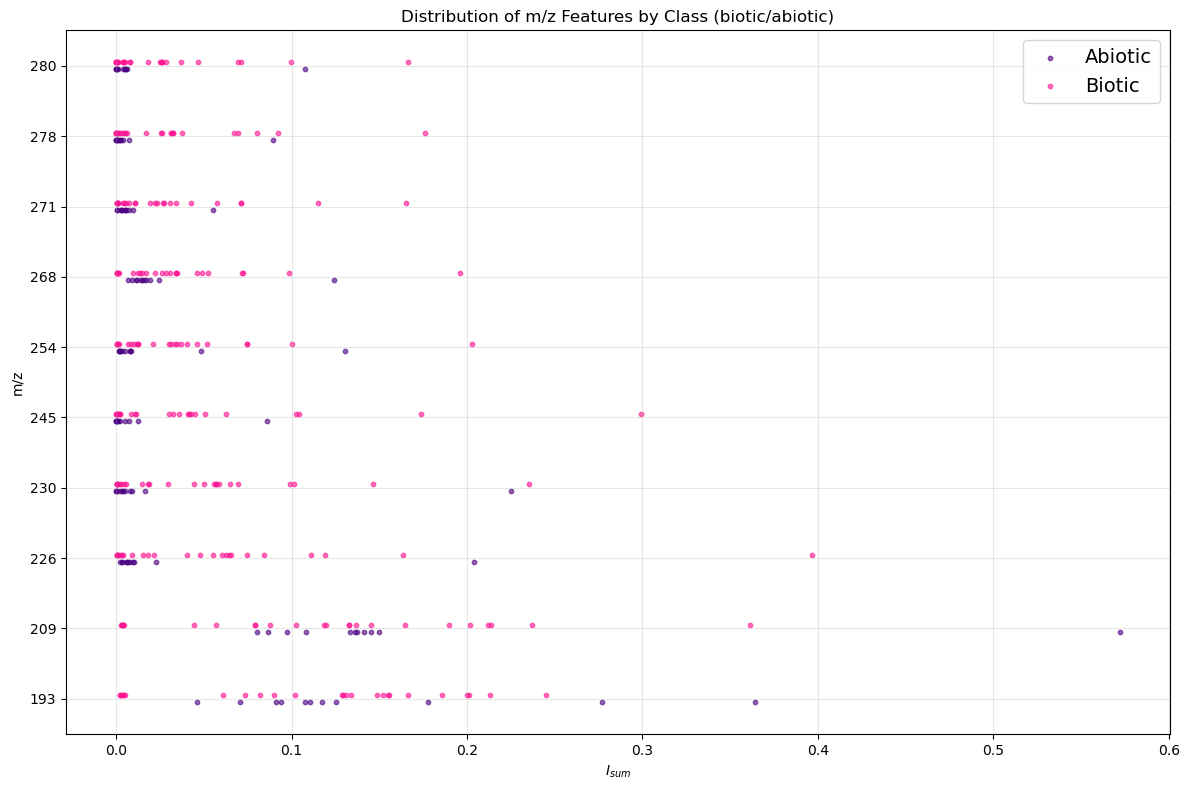

In [19]:
# Creating strip plot-like figure:
plt.figure(figsize=(12, 8))

# Reshaping data into 'long' format:
melted = (
    X_train_reduced[outlier_features]
    .assign(
        label=np.where(y_train == 0, "Abiotic", "Biotic")
    )  # assigning data points to class
    .melt(id_vars="label", var_name="m/z", value_name="I_sum")
)  # separating columns into m/z and intensity

colours = {"Biotic": "deeppink", "Abiotic": "indigo"}  # assign colors to classes

for i, mz in enumerate(outlier_features):
    subset = melted[melted["m/z"] == mz]
    for label, group in subset.groupby("label"):
        # Manually create jitter to distinguish abiotic/biotic points
        if label == "Biotic":
            offset = 0.05  # above
        else:
            offset = -0.05  # below
        plt.scatter(
            group["I_sum"],
            [i + offset] * len(group),
            color=colours[label],
            alpha=0.6,
            s=10,
            label=label if i == 0 else None,
        )

plt.yticks(range(len(outlier_features)), outlier_features)
plt.xlabel(r"$I_{sum}$")
plt.ylabel("m/z")
plt.title("Distribution of m/z Features by Class (biotic/abiotic)")
plt.grid(True, alpha=0.3)
plt.legend(fontsize=14)
plt.tight_layout()
plt.show()

Prior to performing PCA, I will apply scaling via `StandardScaler()` to reduce the effect of outliers by forcing feature $\sigma = 1$, while preserving the underlying chemical signals.

In [20]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()  # initialise RobustScaler

X_train_scaled = pd.DataFrame(  # fit scaler on training data
    scaler.fit_transform(X_train_reduced),
    columns=X_train_reduced.columns,
    index=X_train_reduced.index,
)
X_test_scaled = pd.DataFrame(  # transform test data
    scaler.transform(X_test_reduced),
    columns=X_test_reduced.columns,
    index=X_test_reduced.index,
)

**Feature Collinearity**

Similarly to the case of outliers, features were not dropped when correlated above the standard threshold of pairwise correlation, $0.75$. In py-GC-MS datasets, strong correlation between $m/z$ features arises due to their underlying fragmentation behaviour rather than redundancy. This is because abundant compounds produce a fragment ion series where multiple $m/z$ features originate from the same molecular backbone and thus are correlated.

This is shown below for pyrolysed lipid and hydrocarbon products, where fragmentation produces an $m/z$ series of hydrocarbon fragment ions separated by $\sim 14$ Daltons. These patterns follow the fragmentation series given by the general chemical formula $C_{n} H_{2n-1}^+$ (Takayama 2023), producing the following masses:

<div align="center">

| n | Formula   | m/z |
|---|-----------|-----|
| 4 | $C_4H_7+$  | 55  |
| 5 | $C_5H_{9}+$  | 69  |
| 6 | $C_6H_{11}+$ | 83  |
| 7 | $C_7H_{13}+$ | 97  |

</div>

Here, the fragment ions are mostly single charged, hence the $m/z$ value numerically represent the ion mass in atomic units (u). Note that the `+' indicates detected ion fragments, and the mass of $C = 12u$. 

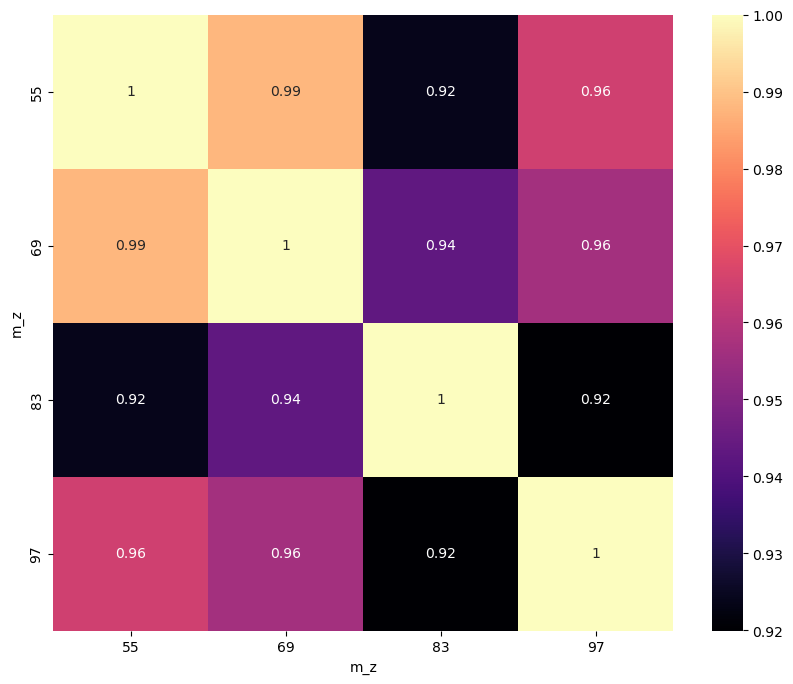

In [21]:
# Feature collinearity check:
plt.figure(figsize=(10, 8))
lipid_features = [55, 69, 83, 97]  # well-known alkyl chain signature
sns.heatmap(X_train_scaled[lipid_features].corr(), annot=True, cmap="magma")
plt.show()

As expected, the aliphatic hydrocarbon series $m/z \in [55, 69, 83, 97]$ demonstrates strong correlation that is not redundant but instead consistent with well-documented fragmentation behaviour (Takayama 2023).

Just like for outliers, tree-based models (Random Forest, XGBoost) are better capable of handling correlated features. However, collinearity across multiple features will ultimately need to be well-regularised for distance-based models (Logistic Regression, SVM).

**Principal Component Analysis (PCA)**

As there are $225$ $m/z$ features, the feature matrix is incredibly high-dimensional and is thus difficult to visualise. PCA aids in this visualisation by identifying the directions of maximum variance using principal components (PCs) $k$. PCs project sample data into a lower-dimensional representation, such that each PC captures a portion of the total variance that enables the first few PCs to encapsulate the major sources of chemical variation across samples. The motivation behind performing PCA is to visually assess whether biotic/abiotic samples separate and cluster in spectral space prior to tree-based and distance-based classification, rather than as a dimensionality reduction step. PCA will thus not be used to replace the current feature space containing the engineered $225$ $m/z$ features.

PCA will be initialised with $k = 4$, where a Scree plot will help determine the optimal number of PCs needed for the remainder of the analysis.

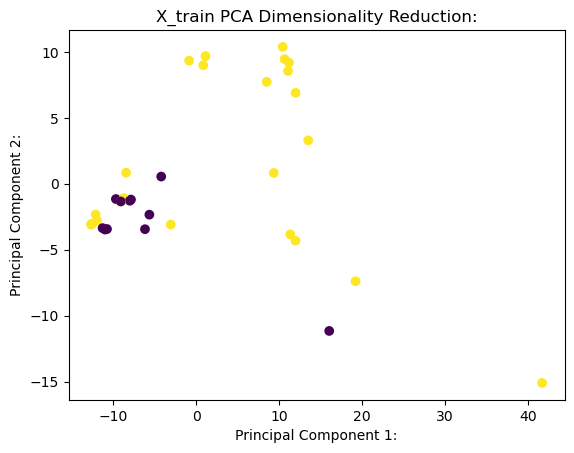

In [22]:
# Initialise PCs
k = 4
pca = PCA(n_components=k)

# Reduce training data into k = 4:
X_train_pca = pca.fit_transform(X_train_scaled)

# Plot PCA-reduced data
plt.scatter(X_train_pca[:, 0], X_train_pca[:, 1], c=y_train)
plt.xlabel("Principal Component 1:")
plt.ylabel("Principal Component 2:")
plt.title("X_train PCA Dimensionality Reduction:")
plt.show()

Variance across k = 1: 0.655
Variance across k = 2: 0.154
Variance across k = 3: 0.045
Variance across k = 4: 0.029


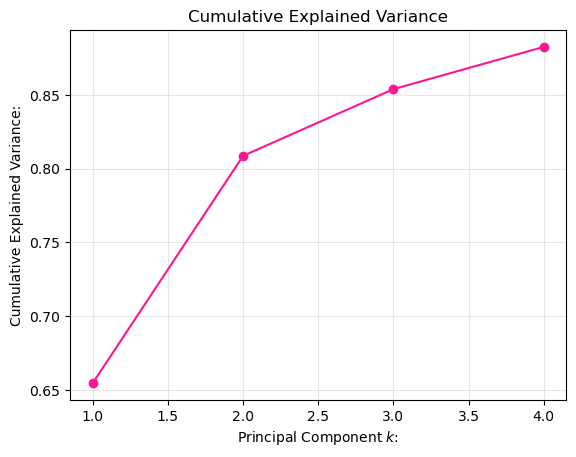

In [23]:
# Find out how much variance captured by each k:
explained_var = pca.explained_variance_ratio_
cum_var = explained_var.cumsum()

# Show the variance per k:
print(f"Variance across k = 1: {explained_var[0]:.3f}")
print(f"Variance across k = 2: {explained_var[1]:.3f}")
print(f"Variance across k = 3: {explained_var[2]:.3f}")
print(f"Variance across k = 4: {explained_var[3]:.3f}")

# Plot cumulative explained variance across k:
plt.plot(
    np.arange(1, len(explained_var) + 1),
    np.cumsum(explained_var),
    marker="o",
    color="deeppink",
)
plt.xlabel("Principal Component $k$:")
plt.ylabel("Cumulative Explained Variance:")
plt.title("Cumulative Explained Variance")
plt.grid(True, alpha=0.3)

In order to choose the optimal $k$ that will balance the trade-off between compression and performance, I will observe the elbow point of a Scree plot where explained variance begins to level off and plateau.

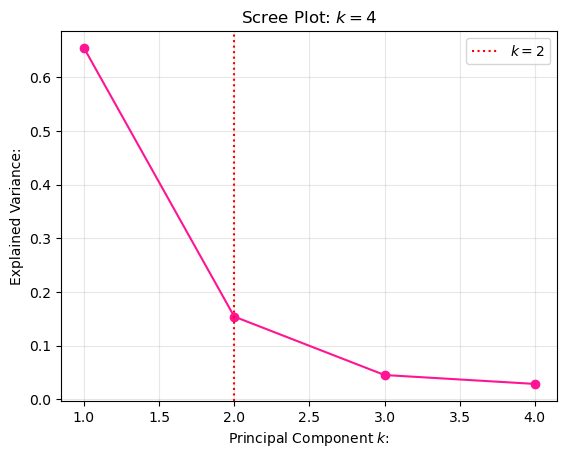

In [24]:
# Scree Plot for k = 4:
plt.plot(range(1, len(explained_var) + 1), explained_var, marker="o", color="deeppink")
plt.xlabel(f"Principal Component $k$:")
plt.ylabel("Explained Variance:")
plt.axvline(2.0, linestyle=":", color="r", label=f"$k = 2$")
plt.legend()
plt.title(f"Scree Plot: $k = {k}$")
plt.grid(True, alpha=0.3)
plt.show()

As the Scree plot shows that the elbow point occurs at $k = 2$, with PC1 and PC2 explaining $65.5\%$ and $15.4\%$ of the total variance, the number of PCs that will be kept for the remainder of my analysis will be $2$.

Having projected training data onto PC1 and PC2 above, it is clear that there are clusters and it would be highly informative to investigate whether these are driven by biotic/abiotic class characteristics. This can be performed by assigning colours to the two classes, as shown below.

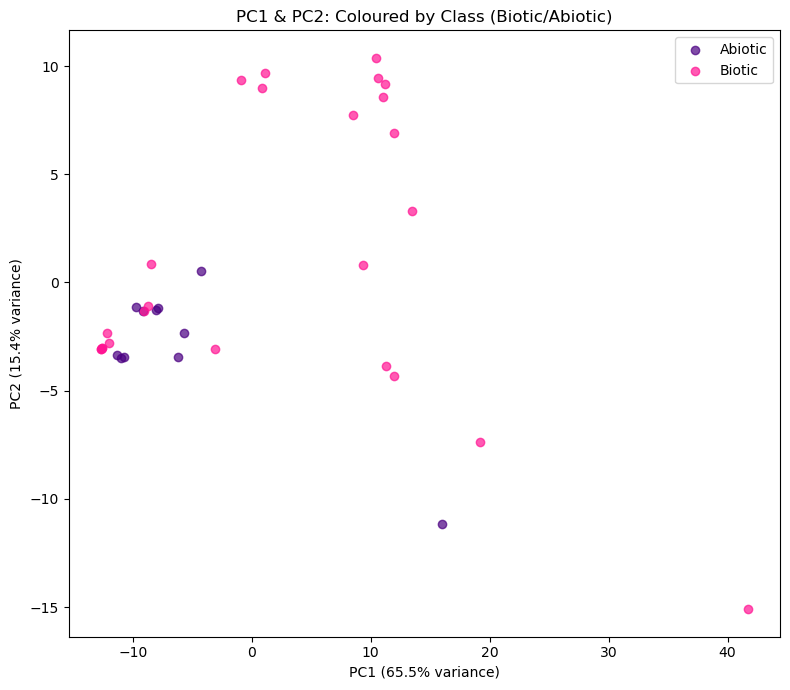

In [25]:
# Plotting abiotic/biotic points across PC1 & PC2:
plt.figure(figsize=(8, 7))

# Abiotic class points:
plt.scatter(
    X_train_pca[y_train == 0, 0],
    X_train_pca[y_train == 0, 1],
    label="Abiotic",
    color="indigo",
    alpha=0.7,
)

# Biotic class points:
plt.scatter(
    X_train_pca[y_train == 1, 0],
    X_train_pca[y_train == 1, 1],
    label="Biotic",
    color="deeppink",
    alpha=0.7,
)

# Plot formatting:
plt.xlabel(f"PC1 ({explained_var[0]*100:.1f}% variance)")
plt.ylabel(f"PC2 ({explained_var[1]*100:.1f}% variance)")
plt.title("PC1 & PC2: Coloured by Class (Biotic/Abiotic)")
plt.legend()
# plt.grid(True, alpha=0.3)
plt.tight_layout()

It appears that abiotic samples cluster tightly together in PC1-PC2 spectral space, while biotic samples are far more spread out with some overlap with the abiotic cluster. This nicely demonstrates the underlying chemistry of the abiotic samples (meteorites, abiotic petroleum-derived waxes, minerals, and plastics) that are simple and relatively homogenous. The biotic samples (bacteria, kerogens, biochars ranging from barley straw to rice husk, membrane lipids, and coal), on the other hand, are far more chemically diverse and therefore occupy a larger region of spectral PC space.

To determine whether the spread of biotics is indicative of its true sub-class chemical structure, both biotics and abiotics will be colour-coded according to their sample type within their biotic/abiotic class.

In [26]:
# Categorise sample names into sample type for PCA visualisation:


def classify_sample(name, cats):
    """
    Helper function for classifying samples into
    provided categories, by matching substrings in
    `cats` to sample name and returning category label.

    Parameters
    ----------
    name : str
        Sample name to be classified.
    cats : dict
        Dictionary where keys are matched with substrings
        in `name`, and values are class labels.

    Returns
    -------
    str
        Matched category label for the sample, or 'Other'
        if no match is found.
    """
    for key, cat in cats.items():
        # for multiple categories listed
        if isinstance(key, tuple):
            if any(sub in name for sub in key):
                return cat
        # for single category
        else:
            if key in name:
                return cat
    # if sample name is not in key + has no category
    return "Other"  # category = 'Other'


categories = {
    "SHEW": "Shewanella",
    ("_CH", "CHLOR"): "Chlorella",
    "SP": "Spirulina",
    ("KEROGEN", "WC", "WL", "CBN", "CD3", "LF1", "RMP1", "GRS"): "Kerogen",
    ("BARLEY", "CHESTNUT", "CW", "PINE", "PB", "RICE", "EUCALYPTUS"): "Biochar",
    "CELLULOSE": "Cellulose",
    "LIGNIN": "Lignin",
    ("PP", "PS", "PVC"): "Plastics",
    ("AMBER", "FRANK", "DAMMAR", "MYRRH", "ROSIN"): "Resin",
    ("WAX", "CARNAUBA", "MICRO"): "Wax",
    ("LOWVOL", "HIGHVOL", "DM_"): "Coal",
    ("MURCHISON", "WINC", "ALLENDE", "NWA"): "Meteorite",
    ("CACO3", "GOET", "MAG", "KAOL", "NONT", "SERP"): "Mineral",
    "MEMBRANE": "Membrane Lipid",
}

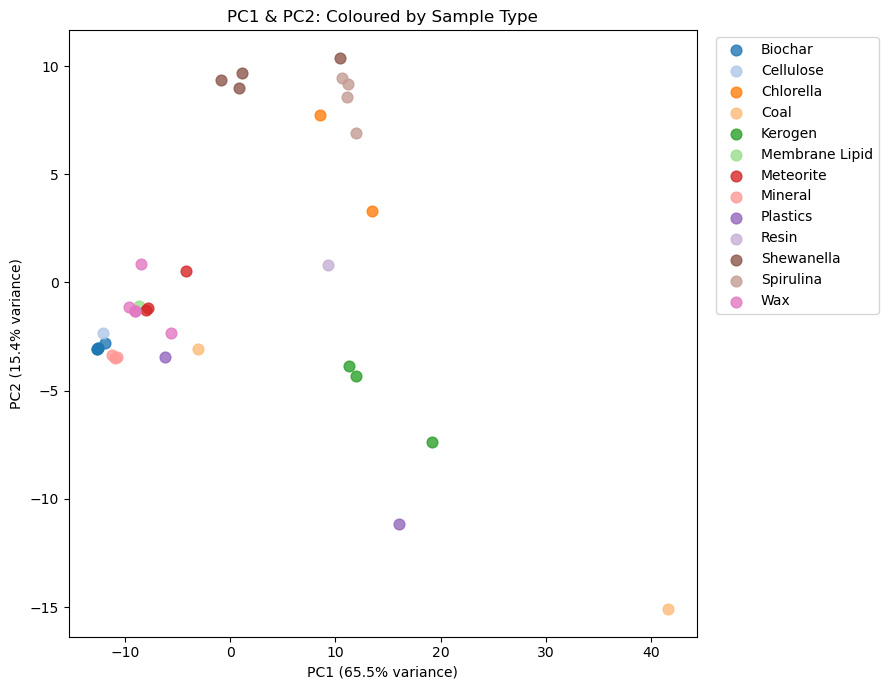

In [27]:
# Plotting PC1 and PC2 and colour-coding different sample categories
# beyond biotic/abiotic class to search for sample-type specific clusters.

plt.figure(figsize=(9, 7))
sample_type = [classify_sample(name, categories) for name in X_train_reduced.index]
colors = plt.get_cmap("tab20").colors  # unique colors for > 20 categories

for colour, group in zip(colors, np.unique(sample_type)):
    mask = np.array(sample_type) == group
    plt.scatter(
        X_train_pca[mask, 0],
        X_train_pca[mask, 1],
        color=colour,
        label=group,
        s=60,
        alpha=0.8,
    )

plt.xlabel(f"PC1 ({explained_var[0]*100:.1f}% variance)")
plt.ylabel(f"PC2 ({explained_var[1]*100:.1f}% variance)")
plt.title("PC1 & PC2: Coloured by Sample Type")
# move legend out of plot:
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
# plt.grid(True, alpha=0.3)
plt.tight_layout()

The sample-type colour-coded PCA plot above illustrates several sub-clusters revealing of their underlying chemistry, and consequently validates my feature engineering framework. For example, the biotic *Shewanella* is clustered in an isolated region within high PC2 values, while the also biotic kerogens are clustered at mid-PC1 and low PC2 values. Several individual abiotic sample-types (minerals, fatty acids, palmitic acid) are tightly clustered together at negative PC1 values as well. This is promising, as the feature matrix largely captures chemical structures that could be helpful for a classifier to discriminate between biotic/abiotic examples.

Nevertheless, to investigate the cluster at negative PC1 values further, the plot below reveals the chemical heterogeneity observed at an overlap of abiotic-biotic sample types.

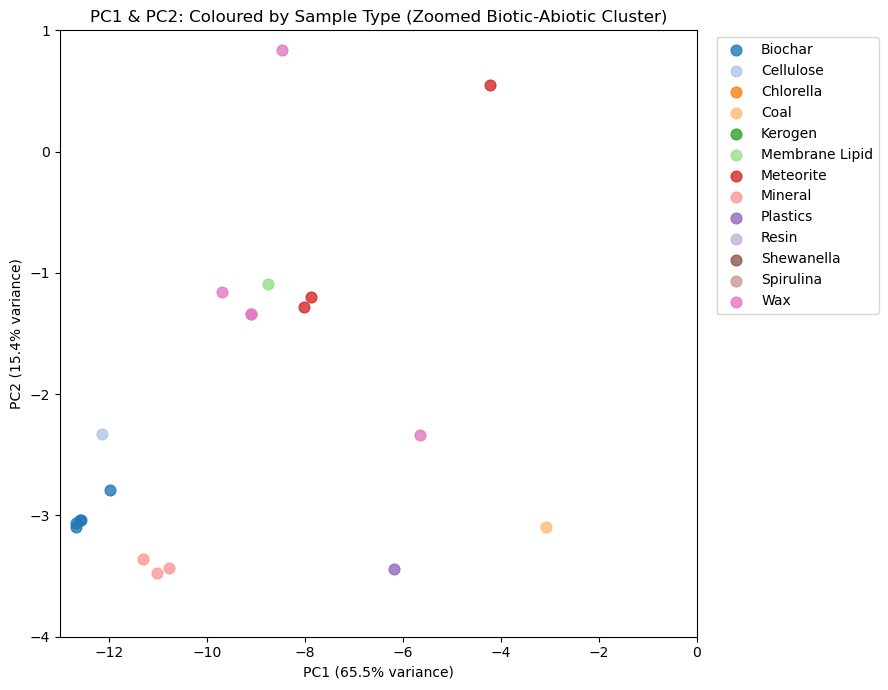

In [36]:
plt.figure(figsize=(9, 7))
for colour, group in zip(colors, np.unique(sample_type)):
    mask = np.array(sample_type) == group
    plt.scatter(
        X_train_pca[mask, 0],
        X_train_pca[mask, 1],
        color=colour,
        label=group,
        s=60,
        alpha=0.8,
    )
plt.xlabel(f"PC1 ({explained_var[0]*100:.1f}% variance)")
plt.ylabel(f"PC2 ({explained_var[1]*100:.1f}% variance)")
plt.title("PC1 & PC2: Coloured by Sample Type (Zoomed Biotic-Abiotic Cluster)")
plt.ylim(-4, 1)
plt.xlim(-13, 0)
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
# plt.grid(True, alpha=0.3)
plt.tight_layout()

In this cluster, it appears that abiotic minerals, plastics, and meteorites as well as biotic waxes, biochar, cellulose, and membrane lipids share similar spectral profiles within PC1-PC2 space. This implies that biotic classification will not be based on spectral similarity alone, as geochemical materials' py-MS vectors resemble those of biological origin.

While the above PCA plots demonstrate which sample class and type tend to cluster together, PCA loadings will now be explored to determine which $m/z$ features are driving each PC (Legendre 1998, Swan et al. 1995, Theiling et al. 2007). Loadings describe how much each $m/z$ feature contributes to a specific PC by indicating on a scale of $[-1, +1]$ how strongly that feature influences a samples position along PC1. This could be incredibly revealing, in terms of biotic classification, as to how the $m/z$ features with high PC1 loadings might correspond to known biological fragment ions.

To calculate the loadings of a given PC, one can use the following equation (Chouinard 2023):

$$\text{Loadings} = \phi \times \sqrt{\lambda} $$

where $\phi$ are the eigenvectors (i.e., the directions of the PCs) of the covariance matrix formed from the calculated covariance of every pair of features, and $\lambda$ are the eigenvalues capturing the magnitude of the corresponding $\phi$. The loadings for PC1 and PC2 will then be subsequently plotted to determine the $m/z$ values driving clustering in PC space and to analyse for underlying biological/geochemical relationships.

In [29]:
# Loadings to find contribution of each m/z feature to PC1 & PC2:
loadings = (pca.components_.T) * (np.sqrt(pca.explained_variance_))
loadings_df = pd.DataFrame(
    loadings,  # rows = m/z, columns = PCs
    index=X_train_scaled.columns,  # m/z values
    columns=["PC1", "PC2", "PC3", "PC4"],
)

# Check loadings for first 5 m/z features:
loadings_df.head(5)

,PC1,PC2,PC3,PC4
m_z,,,,
40,0.209166,-0.338401,0.569045,0.093877
41,0.337336,-0.269952,0.560465,0.168430
42,0.288003,-0.284037,0.568555,0.140450
43,0.314083,-0.276828,0.567414,0.156801
45,0.127570,0.542157,-0.017565,-0.486566


In [ ]:
# Plotting loadings to visualise m/z feature effect on PCA:


def plot_loadings(pc_loadings, pc_name, n=15):
    # Obtain largest and smallest 15 loadings
    top = pd.concat([pc_loadings.nsmallest(n), pc_loadings.nlargest(n)])
    # Rank loadings in descending order (top -> bottom ordering):
    top = top.reindex(top.abs().sort_values(ascending=False).index)
    colours = [
        "indigo" if x < 0 else "deeppink" for x in top
    ]  # pink = +ve, purple = -ve

    # Plot horizontal bar chart:
    fig, ax = plt.subplots(figsize=(7, 7))
    ax.barh(top.index.astype(str), top.values, color=colours, edgecolor="none")

    # Formatting:
    ax.spines["top"].set_visible(False)  # remove plotting box
    ax.spines["bottom"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_visible(False)
    ax.tick_params(axis="y", length=0)  # remove tick marks
    ax.set_xlabel("Loadings:")
    ax.set_ylabel("m/z:")
    ax.set_title(f"Top {n} {pc_name} Loadings:")
    plt.tight_layout()
    plt.show()

Top 5 m/z features for PC1 (+ve direction):
m_z
201    1.000316
182    0.996341
190    0.994089
176    0.991544
200    0.988243
Name: PC1, dtype: float64

Top 5 m/z features for PC1 (-ve direction):
m_z
48   -0.024117
64    0.100735
46    0.107537
45    0.127570
40    0.209166
Name: PC1, dtype: float64


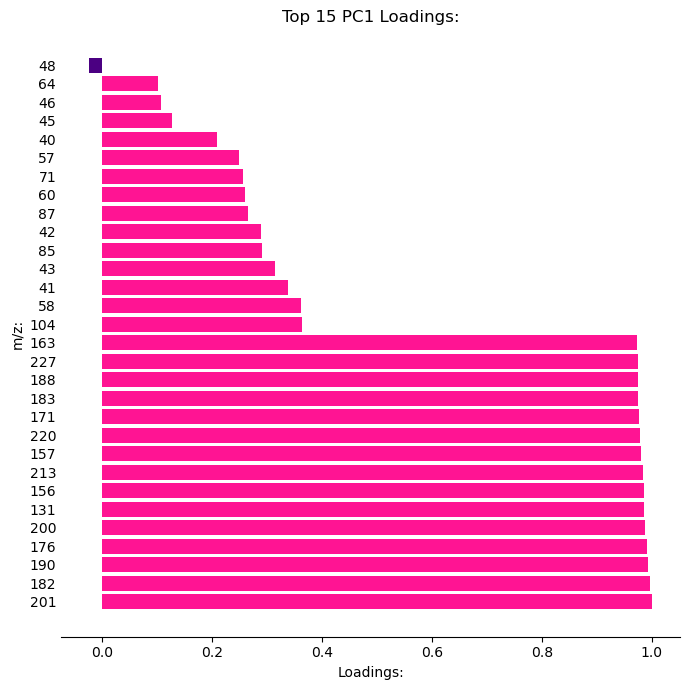

In [31]:
# Top 5 m/z features for +ve and -ve PC1:
pc1_loadings = loadings_df["PC1"].sort_values()

# Print PC1 values:
print("Top 5 m/z features for PC1 (+ve direction):")  # +ve
print(pc1_loadings.tail(5).sort_values(ascending=False))
print("\nTop 5 m/z features for PC1 (-ve direction):")  # -ve
print(pc1_loadings.head(5))

# Plot top 15 PC1 loadings:
plot_loadings(pc1_loadings, "PC1")

As PC1 explains $\sim 66 \%$ of the total variance across all $m/z$ features, the above fragment ions thus represent the $m/z$ driving essentially over half of the chemical variation across the entire dataset. It is interesting to see that the $m/z$ features which strongly influence positive PC1 values are high-mass and occupy a specific mass range ($\sim$ $m/z$ $150-220$). This suggests that the dominant source of cluster separation in PC1 is driven by high molecular weight ions. On the other hand, the tail end of PC1 is influenced by lighter fragment ions, such as $m/z$ $40, 42, 45, 46, 48$.

The main separation along PC1 is thus the PAH-rich mature material like coal and kerogens versus aliphatic/lipid-dominated organic material such as biochar, bacteria, and waxes.

Top 5 m/z features for PC2 (+ve direction):
m_z
72    0.849450
54    0.833965
84    0.833034
68    0.829898
59    0.827355
Name: PC2, dtype: float64

Top 5 m/z features for PC2 (-ve direction):
m_z
252   -0.484801
302   -0.483784
316   -0.474989
266   -0.473898
276   -0.467028
Name: PC2, dtype: float64


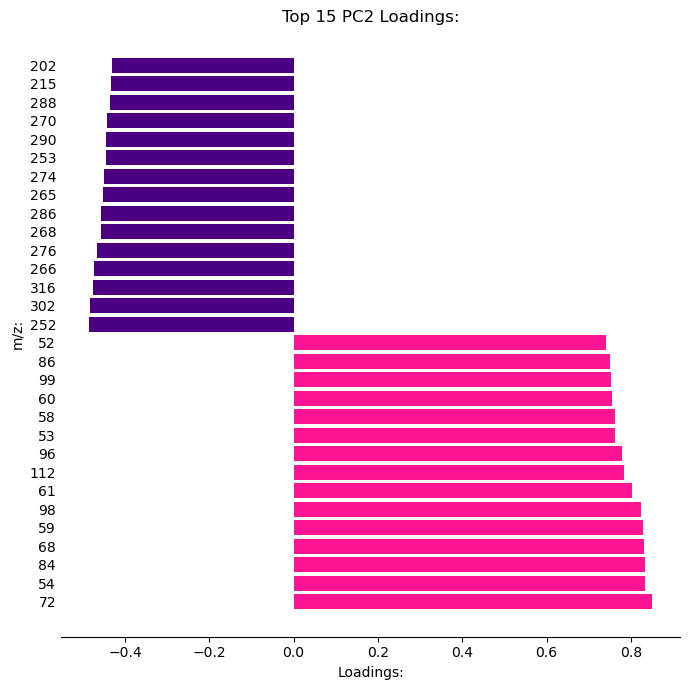

In [32]:
# Top 5 m/z features for +ve and -ve PC1:
pc2_loadings = loadings_df["PC2"].sort_values()

# Print PC1 values:
print("Top 5 m/z features for PC2 (+ve direction):")  # +ve
print(pc2_loadings.tail(5).sort_values(ascending=False))
print("\nTop 5 m/z features for PC2 (-ve direction):")  # -ve
print(pc2_loadings.head(5))

# Plot top 15 PC2 loadings:
plot_loadings(pc2_loadings, "PC2")

Unlike PC1, positive PC2 values appear to be characterised by smaller fragment ions largely between $m/z$ $54 - 98$. On the other hand, the negative direction of PC2 is influenced by fragment ions far heavier than those dominating positive PC1 values, implying that PC2 seems to separate higher mass fragment ions againts lower mass ones.

**t-distributed stochastic neighbour embedding (t-SNE)**

Following scikit-learn developers (2026), t-SNE is employed for visualising high-dimensional data similar to PCA, except t-SNA is non-linear and not mathematically interpretable like linear PCA but offers far more flexibility in exploring underlying structures. Hence, PCA is more strongly recommended for dimensionality reduction strategies with many features, where in this notebook there are $<200$. Nevertheless, PCA and t-SNE in this work are used purely for exploring hidden clusters of features that belong to the same class or sample-type. As van der Maaten (2008) guides that the hyperparameter `perplexitiy` $\in [5, 50]$, I will be employing the strategy described in Wattenberg (2016) by initially analysing multiple plots with different `perplexity` value that are lower than the number of data points.

In [33]:
# Function for plotting t-SNE coloured by sample-type:


def plot_tsne(ax, X, sample_type, perplexity):
    """
    Compute and plots a 2-D t-SNE embedding coloured by py-GC-MS
    sample type for a given perplexity.

    Parameters
    ----------
    ax : matplotlib.axes.Axes
        Axes to plot onto, subject to number of perplexity
        values.
    X : pandas.DataFrame
        Feature matrix to perform t-SNE embedding.
    sample_type : list[str]
        Sample type label for each row (sample) in feature
        matrix, X.
    perplexity : int
        t-SNE perplexity hyperparameter that controls balance
        between local and global structure with values [5, 50].
    """
    tsne = TSNE(
        n_components=2,  # only 2 dimensional data
        perplexity=perplexity,
        max_iter=1000,
        random_state=42,  # for reproducibility
    )
    X_tsne = tsne.fit_transform(X)  # fitting to X features
    # Plotting t-SNE clusters:
    colors = plt.get_cmap("tab20").colors
    for colour, group in zip(colors, np.unique(sample_type)):
        mask = np.array(sample_type) == group
        ax.scatter(
            X_tsne[mask, 0], X_tsne[mask, 1], color=colour, label=group, s=40, alpha=0.8
        )
        ax.set_title(f"perplexity = {perplexity}")

c:\Users\lette\anaconda3\envs\biosignature-ml\Lib\site-packages\threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)


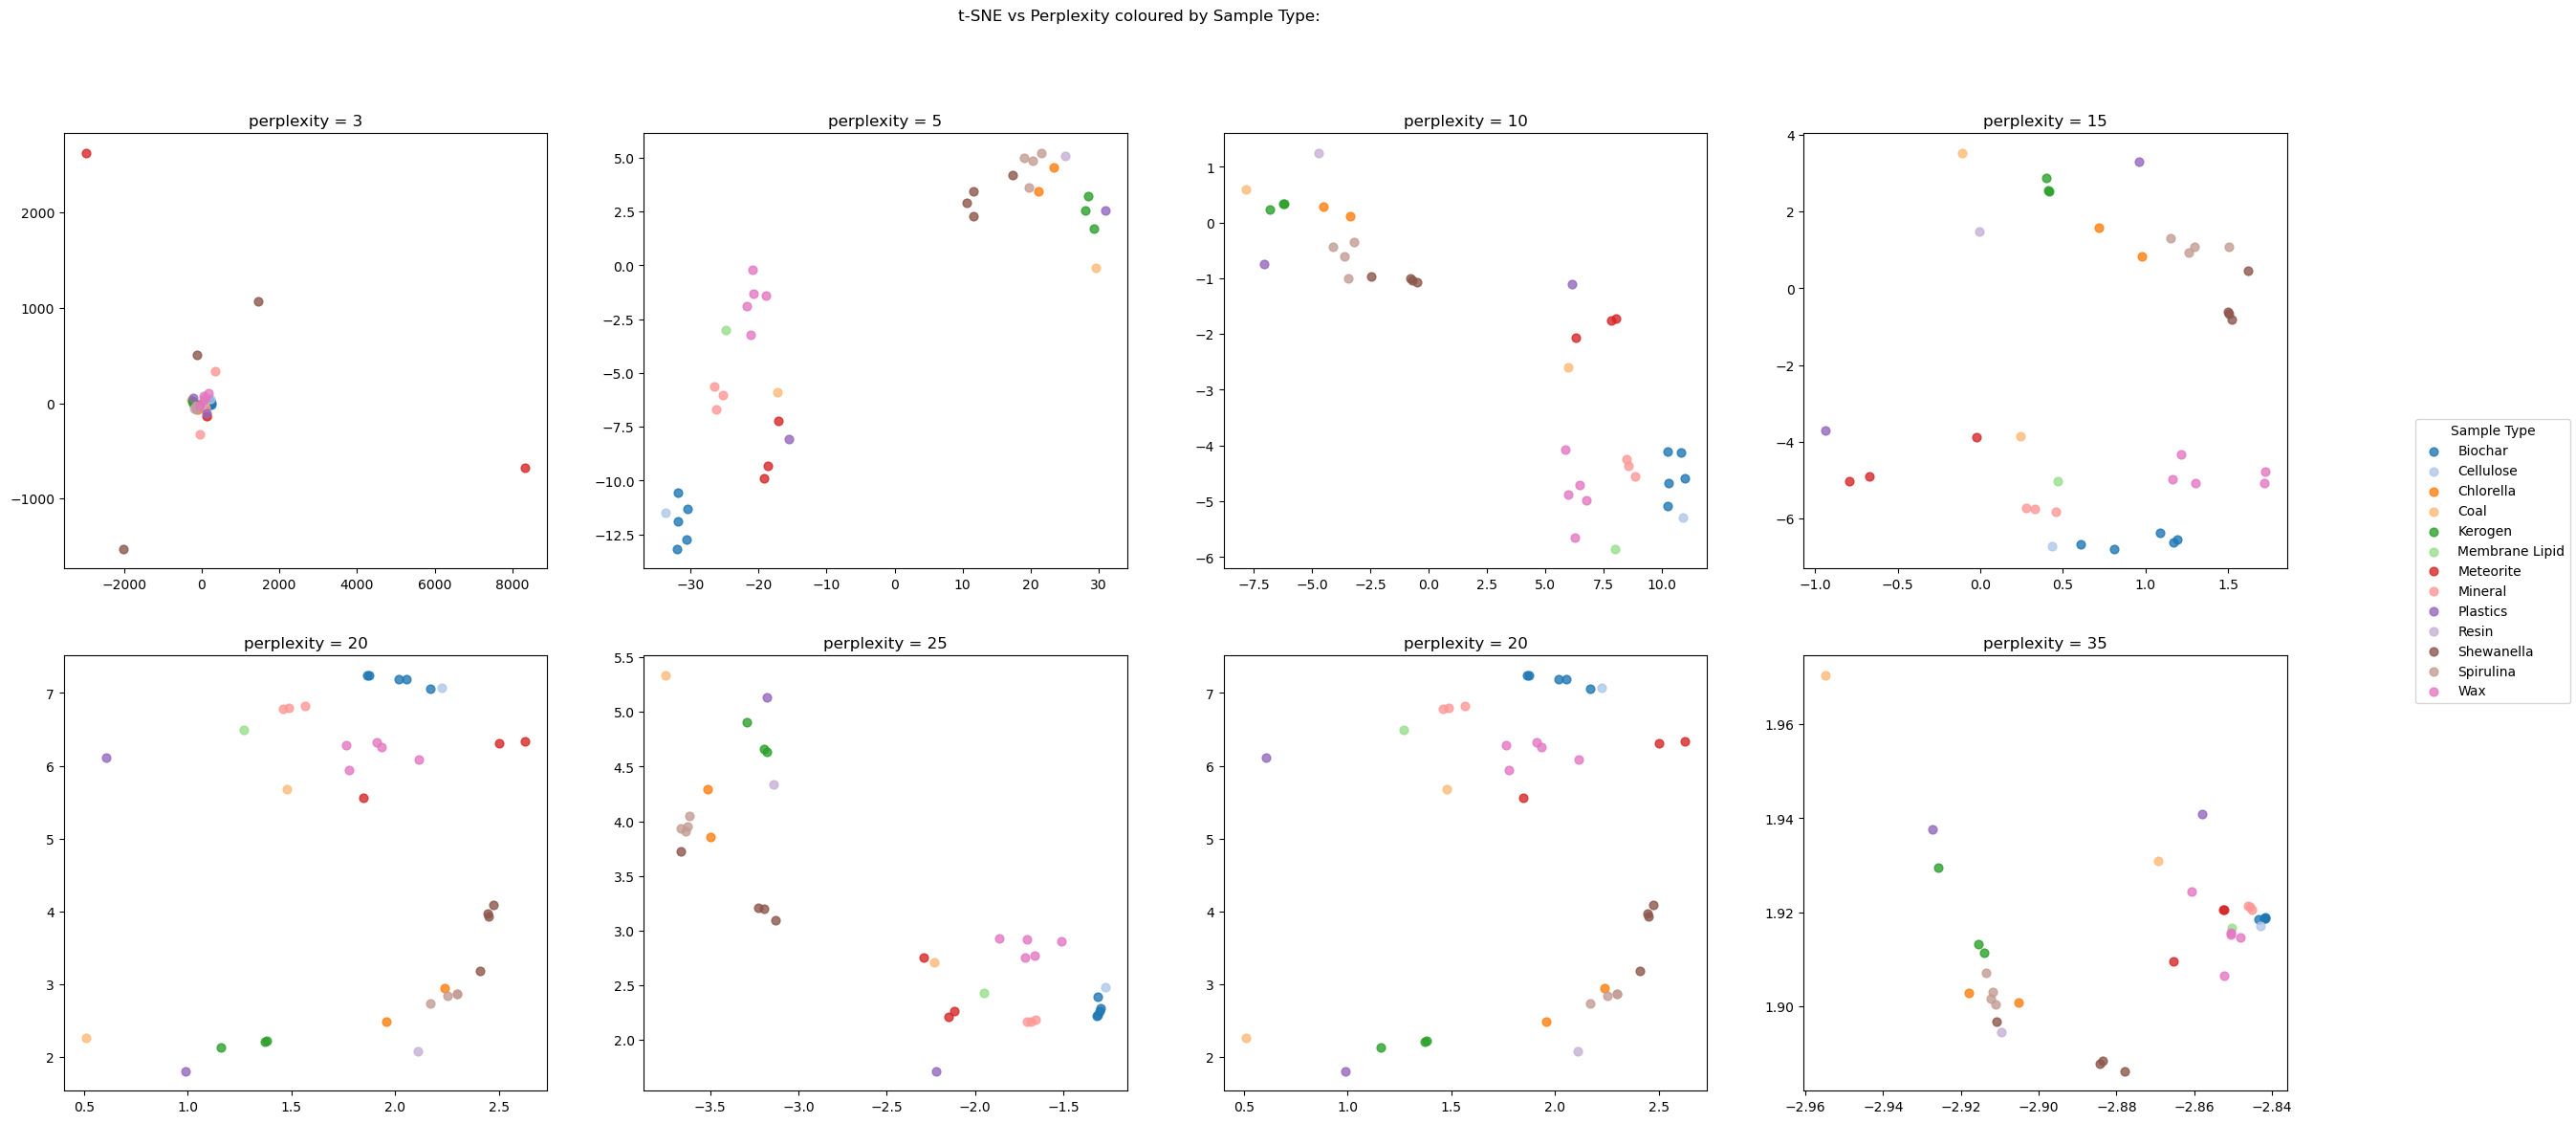

In [34]:
# Plotting different perplexities with clusters coloured by sample type:
perplexities = [3, 5, 10, 15, 20, 25, 20, 35]  # 8 perplexities

fig, axes = plt.subplots(nrows=2, ncols=4, figsize=(30, 13))
axes = axes.flatten()  # flatten grid into array

for ax, p in zip(axes, perplexities):
    plot_tsne(ax, X_train_scaled, sample_type, p)

# Plotting shared legend:
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, title="Sample Type", loc="center right")
fig.suptitle("t-SNE vs Perplexity coloured by Sample Type:")
plt.tight_layout
plt.show()

From the t-SNE comparison plots above, it seems to be suggested that `perplexity = 5` best captures the relationships and separations between different sample types. Lower perplexities result in clusters that are not clearly grouped by sample type due to local neighbourhoods being overly prioritised and considered. However, larger perplexities emphasise global clustering whereby different sample types seem to merge and form long structures rather than defined clusters. This t-SNE exploration serves more as a visual exercise in determining local neighbourhood relationships between sample types, unlike PCA whereby the sizes and positions of clusters translate into mathematically interpretable phenomena.

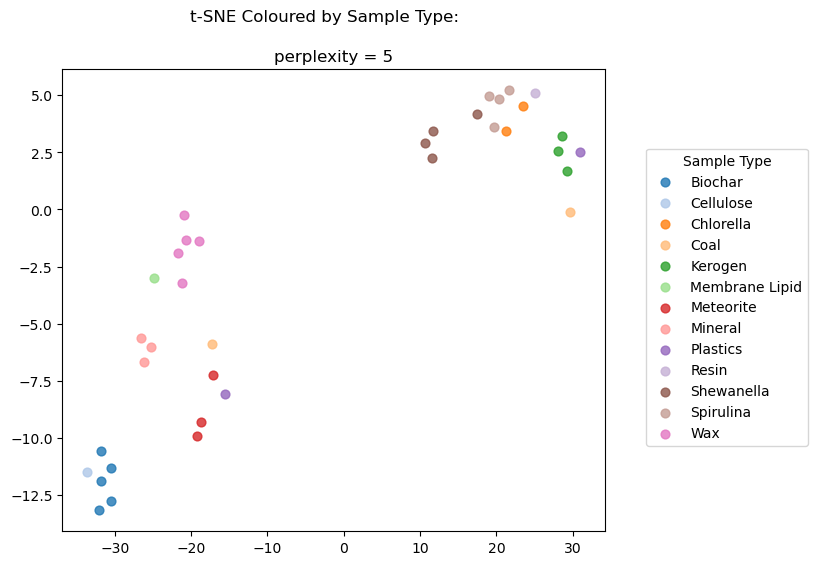

In [39]:
fig, axes = plt.subplots(nrows=1, ncols=1, figsize=(7, 6))
plot_tsne(axes, X_train_scaled, sample_type, perplexity=5)
fig.legend(title="Sample Type", loc="center right", bbox_to_anchor=(1.2, 0.5))
fig.suptitle("t-SNE Coloured by Sample Type:")
plt.show()


### Conclusions:

This notebook outlines the feature engineering framework applied to the preprocessed py-MS feature matrix prior to any ML classification. This details splitting features into training and testing sets,  spectral binning to reduce dimensionality, dropping features associated with known spectral contaminants (atmospheric/background, GC column bleed, and diffusion pump fluid artefacts), variance thresholding to remove noise, and scaling. As part of exploratory data analysis, PCA is applied to validate and thus reveal the chemical interpretability of the final engineered features while t-SNE further supports the local clustering of distinct sample types. Based on this work, I can now proceed in translating this framework into [`feature_engineering.py`](../mlbiosig/feature_engineering.py) to be applied to the full dataset prior to ML classification.

### Bibliography:

Agilent Technologies. (2024). *GC/MS Troubleshooting Guide* (p. 145). https://www.agilent.com/cs/library/catalogs/public/5991-5213EN_GC_Catalog_LR.pdf

Barupal, D.K., Kind, T., Kothari, S.L. et al. (2010). *Hydrocarbon phenotyping of algal species using pyrolysis-gas chromatography mass spectrometry*. BMC Biotechnol 10, 40. https://doi.org/10.1186/1472-6750-10-40

Chouinard, J. C. (2023). *What are PCA Loadings (with Python Example)*. https://www.jcchouinard.com/pca-loadings/

Legendre, P., and L. Legendre. (1998). *Numerical Ecology*. Elsevier: Amsterdam, (p. 853).

Swan, A.R.H., and M. Sandilands. (1995). *Introduction to Geological Data Analysis*. Blackwell Science: Oxford, (p. 446).

Theiling, B.P., L.B. Railsback, S.M. Holland, and D.E. Crowe. (2007). *Heterogeneity in geochemical expression of subaerial exposure in limestones, and its implications for sampling to detect exposure surfaces*. Journal of Sedimentary Research 77:159–169.

scikit-learn developers. (2026). *VarianceThreshold*. https://scikit-learn.org/stable/modules/generated/sklearn.feature_selection.VarianceThreshold.html

scikit-learn developers. (2026). *TSNE*. https://scikit-learn.org/stable/modules/generated/sklearn.manifold.TSNE.html

Solli H., Larter S.R., Douglas A.G. (1980). *Analysis of kerogens by pyrolysis-gas chromatography-mass spectrometry using selective ion monitoring. III. Long-chain alkylbenzenes*. Physics and Chemistry of the Earth. (vol. 12, p. 591-597). https://doi.org/10.1016/0079-1946(79)90141-1.

Takayama M., Ubukata M., Ohshimo K., et al. (2023). *Identification of complementary McLafferty rearrangement ions at m/z 222 and 224 of methylstearate using high-resolution electron ionization time-of-flight mass spectrometer*. International Journal of Mass Spectrometry. (vol. 484). https://doi.org/10.1016/j.ijms.2022.116978

van der Maaten, L., and Hinton, G. (2008). *Visualizing Data using t-SNE*. Journal of Machine Learning Research. (vol. 9, p. 2579-2605). http://jmlr.org/papers/v9/vandermaaten08a.html

Wattenberg, et al. (2016). *How to Use t-SNE Effectively*. Distill. http://doi.org/10.23915/distill.00002
